In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt


In [11]:
def load_results_csvs(folder: Path) -> pd.DataFrame:
    dfs = [pd.read_csv(p) for p in folder.glob("*.csv")]
    return pd.concat(dfs, ignore_index=True)


def to_long_format(df: pd.DataFrame, id_col="Model Name") -> pd.DataFrame:
    return df.melt(
        id_vars=id_col,
        var_name="Metric",
        value_name="Value"
    )


def plot_metrics(
    df: pd.DataFrame,
    metrics: list,
    title: str,
    ylim=(0, 1)
):
    plot_df = df[df["Metric"].isin(metrics)]

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=plot_df,
        x="Metric",
        y="Value",
        hue="Model Name",
        palette="Dark2"
    )
    plt.title(title)
    plt.ylabel("Score")
    plt.xlabel("")
    plt.ylim(*ylim)
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()

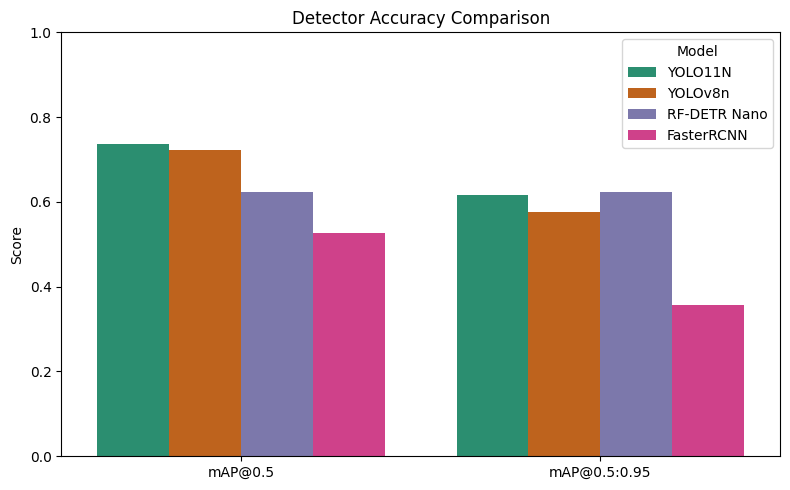

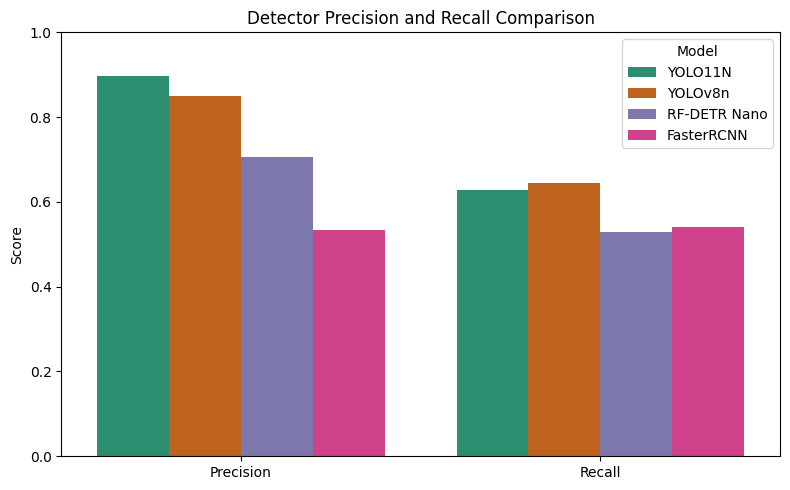

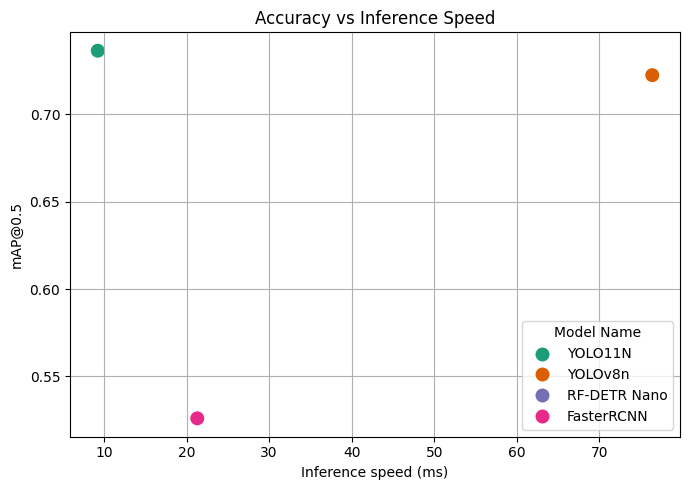

In [12]:
DETECTOR_DIR = Path("Group Results/Detector")

detector_df = load_results_csvs(DETECTOR_DIR)
detector_df = detector_df.sort_values("mAP@0.5", ascending=False)

detector_long = to_long_format(detector_df)

plot_metrics(
    detector_long,
    metrics=["mAP@0.5", "mAP@0.5:0.95"],
    title="Detector Accuracy Comparison"
)

plot_metrics(
    detector_long,
    metrics=["Precision", "Recall"],
    title="Detector Precision and Recall Comparison"
)


plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=detector_df,
    x="Inference speed (ms)",
    y="mAP@0.5",
    hue="Model Name",
    s=120,
    palette="Dark2"
)

plt.title("Accuracy vs Inference Speed")
plt.xlabel("Inference speed (ms)")
plt.ylabel("mAP@0.5")
plt.grid(True)
plt.tight_layout()
plt.show()


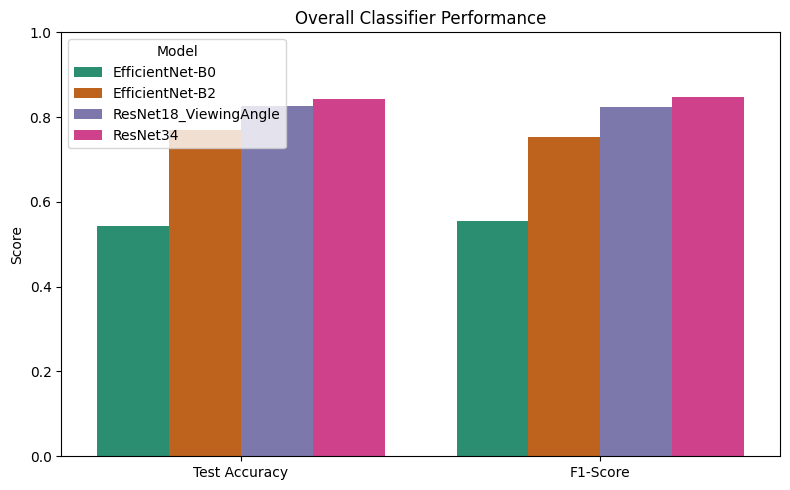

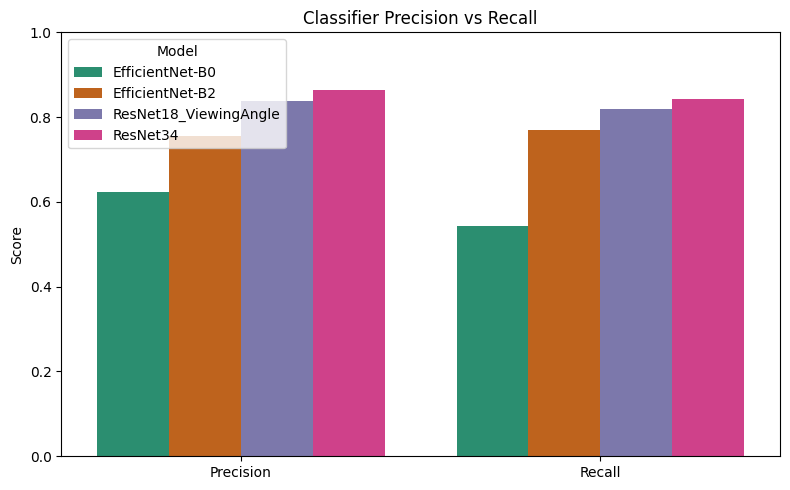

In [13]:
CLASSIFIER_DIR = Path("Group Results/Classifier")

classifier_df = load_results_csvs(CLASSIFIER_DIR)
classifier_long = to_long_format(classifier_df)

plot_metrics(
    classifier_long,
    metrics=["Test Accuracy", "F1-Score"],
    title="Overall Classifier Performance"
)

plot_metrics(
    classifier_long,
    metrics=["Precision", "Recall"],
    title="Classifier Precision vs Recall"
)


In [ ]:
# Model Summary Tables

# Detector Summary (by model)
detector_columns = [
    "Model Name",
    "mAP@0.5",
    "mAP@0.5:0.95",
    "Precision",
    "Recall",
]

detector_summary = (
    detector_df[detector_columns]
    .sort_values("mAP@0.5", ascending=False)
    .round(2)
    .reset_index(drop=True)
)

print("Detector Model Summary:")
print(detector_summary.to_string(index=False))

# Classifier Summary (by model)
classifier_columns = [
    "Model Name",
    "Test Accuracy",
    "F1-Score",
    "Precision",
    "Recall"
]

classifier_summary = (
    classifier_df[classifier_columns]
    .sort_values("Test Accuracy", ascending=False)
    .round(2)
    .reset_index(drop=True)
)

print("\nClassifier Model Summary:")
print(classifier_summary.to_string(index=False))


Detector Model Summary:
  Model Name  mAP@0.5  mAP@0.5:0.95  Precision   Recall
     YOLO11N 0.736529      0.616956   0.897992 0.627710
     YOLOv8n 0.722517      0.576189   0.849977 0.643484
RF-DETR Nano 0.624110      0.624110   0.705484 0.530000
  FasterRCNN 0.525900      0.355800   0.532800 0.541700

Classifier Model Summary:
           Model Name  Test Accuracy  F1-Score  Precision   Recall
             ResNet34       0.842975  0.847800   0.864957 0.842975
ResNet18_ViewingAngle       0.826446  0.823859   0.837533 0.819883
      EfficientNet-B2       0.768595  0.754136   0.754934 0.768595
      EfficientNet-B0       0.544200  0.555900   0.624100 0.544200
